# Trabalho de DL - Tradutor (Transformer) - Versão usando Pytorch - G13

### 1. Importando as bibliotecas

In [1]:
import random

from datasets import load_dataset

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

import math
import os
import random
import numpy as np

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# =====================================================
# Reprodutibilidade
# =====================================================

def set_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # determinismo do PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # força algoritmos determinísticos quando possível
    torch.use_deterministic_algorithms(True)

    g = torch.Generator()
    g.manual_seed(seed)

    print(f"Semente fixada: {RAND_SEED}")
    return(g)



### 2. Escolhendo o Device

In [3]:
# Verificar se temos GPU disponível
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: Tesla T4


### 3. Hyperparâmetros

In [4]:
# Hyperparâmetros do trabalho
DATASET_NAME = "VanessaSchenkel/translation-en-pt"
DATASET_OPT = "default"
RAND_SEED = 13             # Em homenagem ao grupo!
NUM_SAMPLES = 50000        # Número de amostras do dataset
TRAIN_SIZE = 0.8           # proporcão das amostras para trein0
BATCH_SIZE = 32            # Tamanho de cada mini batch
#VOCAB_SIZE = 16000        # Tamanho do vocabulário do Tokenizador
MAX_TEXT_LENGTH = 128      # Limita o tamanho máximo do texto
D_MODEL = 128              # Dimensões do modelo
NUM_HEADS = 8              # Número de cabeças do mecanismo de atenção
NUM_ENCODER_LAYERS = 4     # Número de camadas de encoder e decoder
D_FF = 256                 # Dimensões do Feed Forward
DROPOUT = 0.1              # Taxa de dropout
TRAIN_ONLY = False         # Flag que informa que irá fazer apenas o Treino, sem validar
LOAD_PRE_TRAINED = False   # Flag para carregar os pesos já treinados - não realiza novo treino

In [5]:
g = set_seed(RAND_SEED)

Semente fixada: 13


### 4. Carregando os dados

In [6]:
dataset = load_dataset(DATASET_NAME, DATASET_OPT)


README.md:   0%|          | 0.00/743 [00:00<?, ?B/s]

translate-en-pt.json: reconstructing file:   0%|          |  0.00B / 59.8MB            

translate-en-pt.json: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

In [7]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 260482
    })
})


In [8]:
# 260K de amostras é muita coisa, reduzindo a base para NUM_SAMPLES
dataset = dataset["train"].shuffle(seed=RAND_SEED).select(range(NUM_SAMPLES)) # Escolha aleatória

In [9]:
print(dataset[0]) # primeira amostra
print(dataset[-1]) # última amostra

{'data': {'id': '89446', 'translation': {'english': "Tom doesn't live very far away.", 'portuguese': 'Tom não mora muito longe.'}}}
{'data': {'id': '141975', 'translation': {'english': "They won't know we're there.", 'portuguese': 'Elas não saberão que estamos lá.'}}}


In [10]:
# Escolha 5 amostras
rng = random.Random(RAND_SEED)

for i in rng.sample(range(NUM_SAMPLES), 5):

    sample = dataset[i]["data"]["translation"]

    print("Inglês    :", sample["english"])
    print("Português :", sample["portuguese"])
    print("-"*60)

Inglês    : Your cough worries me.
Português : Sua tosse me preocupa.
------------------------------------------------------------
Inglês    : Tom, call Mary as soon as possible.
Português : Tom, telefone para a Mary logo que puder.
------------------------------------------------------------
Inglês    : Tom is still uncertain about whether to go to college or not.
Português : Tom ainda está inseguro se deve ir à faculdade ou não.
------------------------------------------------------------
Inglês    : I'm looking for a job.
Português : Procuro um emprego.
------------------------------------------------------------
Inglês    : How did you know we were at Tom's house?
Português : Como você sabia que estávamos na casa de Tom?
------------------------------------------------------------


### 5. Separando o Treino, Validação e Teste

In [11]:
from sklearn.model_selection import train_test_split

# índices de todas as amostras
idx_samples = list(range(NUM_SAMPLES))

# --------------------------------------------------
# 1) treino (80%) e temporário (20%)
# --------------------------------------------------
idx_train, idx_temp = train_test_split(
    idx_samples,
    train_size=TRAIN_SIZE,
    random_state=RAND_SEED,
    shuffle=True
)

# --------------------------------------------------
# 2) validação (10%) e teste (10%)
# --------------------------------------------------
idx_valid, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    random_state=RAND_SEED,
    shuffle=True
)

print(f"Total     : {len(idx_samples)}")
print(f"Treino    : {len(idx_train)}")
print(f"Validação : {len(idx_valid)}")
print(f"Teste     : {len(idx_test)}")

Total     : 50000
Treino    : 40000
Validação : 5000
Teste     : 5000


In [12]:
# Criando os datasets de treino, validação e teste
train_ds = dataset[idx_train]["data"]
valid_ds = dataset[idx_valid]["data"]
test_ds =  dataset[idx_test]["data"]

In [13]:
# Separando os idiomas
train_en = [
    exemplo["translation"]["english"]
    for exemplo in train_ds
]

train_pt = [
    exemplo["translation"]["portuguese"]
    for exemplo in train_ds
]

In [14]:
valid_en = [
    exemplo["translation"]["english"]
    for exemplo in valid_ds
]

valid_pt = [
    exemplo["translation"]["portuguese"]
    for exemplo in valid_ds
]

In [15]:
test_en = [
    exemplo["translation"]["english"]
    for exemplo in test_ds
]

test_pt = [
    exemplo["translation"]["portuguese"]
    for exemplo in test_ds
]

In [16]:
# Verificação
print(train_en[0])
print(train_pt[0])


The concert is about to start.
O concerto está quase começando.


### 6. Tokenização

In [17]:
from transformers import AutoTokenizer


In [18]:
# Carrega um Tokenizador
#tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B")
#tokenizer = AutoTokenizer.from_pretrained("NousResearch/Meta-Llama-3-8B-Alternate-Tokenizer")
#tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-7B-Instruct")
#tokenizer = AutoTokenizer.from_pretrained("t5-small")
#tokenizer = AutoTokenizer.from_pretrained("google/mt5-small")
tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased", revision = "main")


VOCAB_SIZE = len(tokenizer) # Inclui os tokens especiais
print("Tamanho do vocabulário é :", VOCAB_SIZE)

PAD_ID = tokenizer.pad_token_id      # 0
BOS_ID = tokenizer.cls_token_id      # 101  ([CLS])
EOS_ID = tokenizer.sep_token_id      # 102  ([SEP])

print("Vocab size:", VOCAB_SIZE)
print("PAD:", PAD_ID)
print("BOS:", BOS_ID)
print("EOS:", EOS_ID)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tamanho do vocabulário é : 29794
Vocab size: 29794
PAD: 0
BOS: 101
EOS: 102


In [19]:
# Função que converte a setença em tokens numéricos (ids)
def encoding(sentence):
    ids = tokenizer.encode( sentence,
                           add_special_tokens=False,
                           truncation=True,
                           max_length=MAX_TEXT_LENGTH -2)

    return [BOS_ID] + ids + [EOS_ID]


In [20]:
# Função que converte os ids de volta ao texto
def decoding(ids):
    if isinstance(ids, torch.Tensor):
        ids = ids.tolist()

    return tokenizer.decode(ids, skip_special_tokens=True)

In [21]:
# Teste
ids_en = encoding("Machine learning is amazing.")
print("EN:", ids_en)
print(decoding(ids_en))

EN: [101, 21537, 447, 8320, 446, 847, 14436, 446, 119, 102]
Machine learning is amazing.


In [22]:
# Teste
ids_pt = encoding("O aprendizado de máquina é incrível.")
print("PT:", ids_pt)
print(decoding(ids_pt))

PT: [101, 231, 17302, 125, 6997, 253, 17399, 119, 102]
O aprendizado de máquina é incrível.


In [23]:
# Teste contendo letras, acentos e números
texto = "O Ministério da Saúde informou que a ação de prevenção à dengue será realizada em \
Belo Horizonte, com distribuição de álcool-gel, vacinação contra a febre amarela e \
atendimento médico-hospitalar às 14h30."
print(decoding(encoding(texto)))

O Ministério da Saúde informou que a ação de prevenção à dengue será realizada em Belo Horizonte, com distribuição de álcool - gel, vacinação contra a febre amarela e atendimento médico - hospitalar às 14h30.


In [24]:
# Retorna uma lista com as strings dos tokens especiais principais
print(tokenizer.all_special_tokens)


# Retorna um dicionário mostrando a função de cada um e seu respectivo ID numérico
print(tokenizer.special_tokens_map)
print(tokenizer.all_special_ids)

['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']
{'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
[100, 102, 0, 101, 103]


O tokenizador utilizado foi baseado no BERTimbau

In [25]:
# Teste
frase = "A maçã é uma fruta"

ids = encoding(frase)

print("Frase :", frase)
print("Tokens:", tokenizer.convert_ids_to_tokens(ids))
print("IDs   :", ids)
print("Decode:", decoding(ids))

Frase : A maçã é uma fruta
Tokens: ['[CLS]', 'A', 'maç', '##ã', 'é', 'uma', 'fru', '##ta', '[SEP]']
IDs   : [101, 177, 13347, 22297, 253, 230, 4502, 154, 102]
Decode: A maçã é uma fruta


### 7. Dataset e Dataloader

In [26]:
# Classe que cria o dataset de ids em formato de tensor com base nas frases
class TranslationDataset(Dataset):
    def __init__(self, samples, tokenizer_fn):
        self.samples = samples
        self.src_samples, self.tgt_samples = zip(*samples)
        self.tokenizer_fn = tokenizer_fn

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src_ids = self.tokenizer_fn(self.src_samples[idx])
        tgt_ids = self.tokenizer_fn(self.tgt_samples[idx])

        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long)
        )

In [27]:
# Função que inclui o padding nas amostras
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=PAD_ID
    )

    tgt_batch = pad_sequence(
        tgt_batch,
        batch_first=True,
        padding_value=PAD_ID
    )

    return src_batch, tgt_batch

In [28]:
# Cria o Dataset e o Dataloader de treinamento

from torch.utils.data import DataLoader
#train_pairs = list(zip(train_pt, train_en))
train_pairs = list(zip(train_en, train_pt)) # invertendo o projeto: tradutor en-pt


train_dataset = TranslationDataset(train_pairs, encoding) # cria o dataset de treinamento

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    generator=g,
    num_workers=0
) # cria o dataloader de treinamento

In [29]:
len(train_dataset) # Total de pares de treino

40000

In [30]:
len(train_loader) # Total de mini-batches de treino

1250

In [31]:
# Teste
one_batch_src, one_batch_tgt = next(iter(train_loader))

print(one_batch_src[0])
print(one_batch_tgt[0])

tensor([  101,   290, 12230,  6954,   174, 22326,   139,  4290, 12406, 12346,
         8512, 22326,  1621,  5294,  7485,   119,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
tensor([  101,   959,  9726,   117,   259, 17080,  4228,   453,  4877,   259,
         2980,   119,   102,     0,     0,     0,     0,     0,     0])


In [32]:
# Teste
print(decoding(one_batch_src[0].tolist()))
print(100*'-')
print(decoding(one_batch_tgt[0].tolist()))

I think my students are simply the best.
----------------------------------------------------------------------------------------------------
Para mim, os meus alunos são simplesmente os melhores.


In [33]:
# Dataload de validação
#valid_pairs = list(zip(valid_pt, valid_en))
valid_pairs = list(zip(valid_en, valid_pt))

valid_dataset = TranslationDataset(
    valid_pairs,
    encoding
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    generator=g,
    num_workers=0
)


In [34]:
# Dataload de teste
#valid_pairs = list(zip(valid_pt, valid_en))
test_pairs = list(zip(test_en, test_pt))

test_dataset = TranslationDataset(
    test_pairs,
    encoding
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    generator=g,
    num_workers=0
)

In [35]:
len(valid_dataset) # Total de pares para validação

5000

In [36]:
len(valid_loader) # batchs para validação

157

In [37]:
src_lengths = [len(item[0]) for item in train_dataset] # obtem os tamanhos das amostras src
tgt_lengths = [len(item[1]) for item in train_dataset] # obtem os tamanhos das amostras tgt

print(f"Tamanho máximo da amostra source: {max(src_lengths)}") # obtem o tamanho da maior amostra src
print(f"Tamanho máximo da amostra target: {max(tgt_lengths)}") # obtem o tamanho da maior amostra tgt

print(f"Tamanho médio da amostra source: {sum(src_lengths) / len(src_lengths):.2f}") # calcula o tamanho médio das amostras src
print(f"Tamanho médio da amostra target: {sum(tgt_lengths) / len(tgt_lengths):.2f}") # calcula o tamanho médio das amostras tgt

Tamanho máximo da amostra source: 128
Tamanho máximo da amostra target: 128
Tamanho médio da amostra source: 15.09
Tamanho médio da amostra target: 10.79


In [38]:
# Teste
one_batch_src, one_batch_tgt = next(iter(train_loader))

print(one_batch_src.shape)  # (BATCH_SIZE, Maior amostra do Source)
print(one_batch_tgt.shape)  # (BATCH_SIZE, Maior amostra do target)


torch.Size([32, 80])
torch.Size([32, 42])


In [39]:
print(decoding(one_batch_src[0].tolist()))
print(decoding(one_batch_tgt[0].tolist()))


Where is the hammer?
Onde está o martelo?


### 8. Embedding

In [40]:
import torch
import torch.nn as nn

embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)

In [41]:
# Verificação do Embedding
def test_embedding():
    vocab_size = VOCAB_SIZE
    d_model = D_MODEL

    emb = nn.Embedding(vocab_size, d_model)

    # entrada sintética
    x = torch.randint(0, vocab_size, (3, 7)).long()

    # forward
    y = emb(x)

    # shape
    assert y.shape == (3, 7, d_model)

    # consistência
    assert torch.allclose(emb(torch.tensor([[1]])),
                          emb(torch.tensor([[1]])))

    # backward
    loss = y.mean()
    loss.backward()

    assert emb.weight.grad is not None

    print("Todos os testes do embedding passaram")

test_embedding()

Todos os testes do embedding passaram


### 9. Positional Encoder

In [42]:
# =====================================================
# Positional Encoding
# =====================================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0, max_len, dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0, d_model, 2,
                dtype=torch.float
            ) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]


In [43]:
# Testa o Positional Encoder
def testa_PE():
    pe = PositionalEncoding(D_MODEL)

    x = torch.zeros(BATCH_SIZE, MAX_TEXT_LENGTH, D_MODEL)

    y = pe(x)
    assert y.shape == x.shape
    assert not torch.allclose(x, y)

    print("PositionalEncoding OK")

testa_PE()

PositionalEncoding OK


### 10. Scaled Dot Product Attention

In [44]:
# =====================================================
# Scaled Dot Product Attention
# =====================================================

class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None):

        d_k = q.size(-1)

        scores = torch.matmul(
            q, k.transpose(-2, -1)
        ) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention = F.softmax(scores, dim=-1)

        output = torch.matmul(attention, v)

        #return output, attention
        return output

### 11. Multi-Head Attention

In [45]:
# =====================================================
# Multi Head Attention
# =====================================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        self.w_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

    def split_heads(self, x):

        batch_size = x.size(0)

        x = x.view(
            batch_size,
            -1,
            self.num_heads,
            self.d_k
        )

        return x.transpose(1, 2)

    def combine_heads(self, x):

        batch_size = x.size(0)

        x = x.transpose(1, 2).contiguous()

        return x.view(
            batch_size,
            -1,
            self.d_model
        )

    def forward(self, q, k, v, mask=None):

        q = self.split_heads(self.w_q(q))
        k = self.split_heads(self.w_k(k))
        v = self.split_heads(self.w_v(v))

        #output, attn = self.attention(
        output = self.attention(
            q,
            k,
            v,
            mask
        )

        output = self.combine_heads(output)

        output = self.w_o(output)

        return output


In [46]:
# Testa o Multi Head Attention
def testa_MHA():
    mha = MultiHeadAttention(D_MODEL, NUM_HEADS)

    x = torch.randn(BATCH_SIZE, MAX_TEXT_LENGTH, D_MODEL)

    y = mha(x, x, x)

    assert y.shape == (BATCH_SIZE, MAX_TEXT_LENGTH, D_MODEL)
    print("Shape OK")

testa_MHA()

Shape OK


### 12. Feed Forward Network

In [47]:
# =====================================================
# Feed Forward Network
# =====================================================

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [48]:
# Teste Feed Forward
ff = PositionwiseFeedForward(d_model=D_MODEL, d_ff=D_FF)

x = torch.randn(3, 7, D_MODEL)
y = ff(x)

assert y.shape == x.shape
print("FeedForward OK")

FeedForward OK


### 13. Encoder Layer

In [49]:
# =====================================================
# Encoder Layer
# =====================================================

class EncoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        self.self_attn = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn = PositionwiseFeedForward(
            d_model,
            d_ff,
            dropout
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):

        attn_output = self.self_attn(
            x, x, x, src_mask
        )

        x = self.norm1(
            x + self.dropout(attn_output)
        )

        ff_output = self.ffn(x)

        x = self.norm2(
            x + self.dropout(ff_output)
        )

        return x

In [50]:
# Teste Encoder Layer

layer = EncoderLayer(d_model=64, num_heads=8, d_ff=256)

# batch=2, seq_len=10
tokens = torch.randint(1, 100, (2, 10))

# adiciona padding
tokens[0, 8:] = PAD_ID

# embeddings de entrada
x = torch.randn(2, 10, 64)

# máscara de padding
x_mask = (tokens != PAD_ID).unsqueeze(1).unsqueeze(2)

print("x:", x.shape)
print("mask:", x_mask.shape)

y = layer(x, x_mask)

assert y.shape == x.shape
assert not torch.allclose(x, y)

print("EncoderLayer OK")

x: torch.Size([2, 10, 64])
mask: torch.Size([2, 1, 1, 10])
EncoderLayer OK


### 14. Decoder Layer

In [51]:
# =====================================================
# Decoder Layer
# =====================================================

class DecoderLayer(nn.Module):
    def __init__(
        self,
        d_model,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        self.self_attn = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.cross_attn = MultiHeadAttention(
            d_model,
            num_heads
        )

        self.ffn = PositionwiseFeedForward(
            d_model,
            d_ff,
            dropout
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x,
        encoder_output,
        src_mask,
        tgt_mask
    ):

        attn = self.self_attn(
            x, x, x, tgt_mask
        )

        x = self.norm1(
            x + self.dropout(attn)
        )

        attn = self.cross_attn(
            x,
            encoder_output,
            encoder_output,
            src_mask
        )

        x = self.norm2(
            x + self.dropout(attn)
        )

        ff = self.ffn(x)

        x = self.norm3(
            x + self.dropout(ff)
        )

        return x


### 15. Encoder

In [52]:
# =====================================================
# Encoder
# =====================================================

class Encoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        num_layers,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.pos_encoding = PositionalEncoding(
            d_model
        )

        self.layers = nn.ModuleList(
            [
                EncoderLayer(
                    d_model,
                    num_heads,
                    d_ff,
                    dropout
                )
                for _ in range(num_layers)
            ]
        )

        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(self, src, src_mask):

        x = self.embedding(src) * math.sqrt(
            self.d_model
        )

        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x, src_mask)

        return x


In [53]:
# Test Encoder
encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_ENCODER_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF
)

# batch=2, seq_len=10
tokens = torch.randint(1, 100, (2, 10))

# adiciona padding
tokens[0, 8:] = PAD_ID

# embeddings de entrada
x = torch.randn(2, 10, 64)

# máscara de padding
x_mask = (tokens != PAD_ID).unsqueeze(1).unsqueeze(2)

print("x:", x.shape)
print("mask:", x_mask.shape)

x = torch.randint(0, VOCAB_SIZE, (2, 10))

y = encoder(x, x_mask)

assert y.shape == (2, 10, D_MODEL)
print("Encoder OK")

x: torch.Size([2, 10, 64])
mask: torch.Size([2, 1, 1, 10])
Encoder OK


### 16. Decoder

In [54]:
# =====================================================
# Decoder
# =====================================================

class Decoder(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        num_layers,
        num_heads,
        d_ff,
        dropout=0.1
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.pos_encoding = PositionalEncoding(
            d_model
        )

        self.layers = nn.ModuleList(
            [
                DecoderLayer(
                    d_model,
                    num_heads,
                    d_ff,
                    dropout
                )
                for _ in range(num_layers)
            ]
        )

        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model

    def forward(
        self,
        tgt,
        encoder_output,
        src_mask,
        tgt_mask
    ):

        x = self.embedding(tgt) * math.sqrt(
            self.d_model
        )

        x = self.pos_encoding(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(
                x,
                encoder_output,
                src_mask,
                tgt_mask
            )

        return x

In [55]:
# Teste Decoder

# instancia o decoder
decoder = Decoder(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_ENCODER_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF
)

# tokens
src = torch.randint(0, VOCAB_SIZE, (2, 10), dtype=torch.long)
tgt = torch.randint(0, VOCAB_SIZE, (2, 10), dtype=torch.long)

# máscaras
src_mask = (src != PAD_ID).unsqueeze(1).unsqueeze(2)
tgt_mask = (tgt != PAD_ID).unsqueeze(1).unsqueeze(2)

# encoder gera float
memory = encoder(src, src_mask)

# decoder recebe tokens inteiros + memória float
y = decoder(tgt, memory, tgt_mask, src_mask)

print(y.shape)

#assert y.shape == (batch_size, tgt_seq_len, D_MODEL)
assert y.shape == (2, 10, D_MODEL)
print("Decoder OK")

torch.Size([2, 10, 128])
Decoder OK


### 17. Transformer

In [56]:
# =====================================================
# Transformer Completo
# =====================================================

class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        d_model=512,
        num_layers=6,
        num_heads=8,
        d_ff=2048,
        dropout=0.1
    ):
        super().__init__()

        self.encoder = Encoder(
            src_vocab_size,
            d_model,
            num_layers,
            num_heads,
            d_ff,
            dropout
        )

        self.decoder = Decoder(
            tgt_vocab_size,
            d_model,
            num_layers,
            num_heads,
            d_ff,
            dropout
        )

        self.fc_out = nn.Linear(
            d_model,
            tgt_vocab_size
        )

    def forward(
        self,
        src,
        tgt,
        src_mask=None,
        tgt_mask=None
    ):

        encoder_output = self.encoder(
            src,
            src_mask
        )

        decoder_output = self.decoder(
            tgt,
            encoder_output,
            src_mask,
            tgt_mask
        )

        output = self.fc_out(
            decoder_output
        )

        return output


In [57]:
# Teste de Transformer

# Cria uma instancia do transformer
model = Transformer(
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_layers=NUM_ENCODER_LAYERS,
    num_heads=NUM_HEADS,
    d_ff=D_FF
)

# cria um source e um target
src = torch.randint(0, VOCAB_SIZE, (2, 12))
tgt = torch.randint(0, VOCAB_SIZE, (2, 8))

# cria máscaras
# máscaras
src_mask = (src != PAD_ID).unsqueeze(1).unsqueeze(2)
tgt_mask = (tgt != PAD_ID).unsqueeze(1).unsqueeze(2)

y = model(src, tgt, src_mask, tgt_mask)

print(y.shape)

assert y.shape == (2, 8, VOCAB_SIZE)
print("Transformer OK")

torch.Size([2, 8, 29794])
Transformer OK


### 18. Máscaras

In [58]:
# =====================================================
# Máscaras
# =====================================================

def create_padding_mask(seq, pad_idx=PAD_ID):
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2)


def create_causal_mask(size):

    mask = torch.tril(
        torch.ones(size, size)
    )

    return mask.bool().unsqueeze(0).unsqueeze(1)

### 19. Aplicação

In [59]:
src_vocab_size = VOCAB_SIZE
tgt_vocab_size = VOCAB_SIZE

model = Transformer(
    src_vocab_size,
    tgt_vocab_size
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)



In [60]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)


In [61]:
# Testando o modelo

src = torch.randint(
    1,
    src_vocab_size,
    (4, 20)
).to(device)

tgt = torch.randint(
    1,
    tgt_vocab_size,
    (4, 15)
).to(device)

src_mask = create_padding_mask(src).to(device)

tgt_input = tgt[:, :-1].to(device)

tgt_output = tgt[:, 1:].to(device)

tgt_mask = (
    create_padding_mask(tgt_input).to(device)
    & create_causal_mask(tgt_input.size(1)).to(device)
)

output = model(
    src,
    tgt_input,
    src_mask,
    tgt_mask
)

loss = criterion(
    output.reshape(-1, output.size(-1)),
    tgt_output.reshape(-1)
)
print(output.shape)
# (4, 14, VOCAB_SIZE)

torch.Size([4, 14, 29794])


### 20. Loop de treinamento

In [62]:
# Instacia o modelo, cria função de Loss e o otimizador

model = Transformer(
    src_vocab_size,
    tgt_vocab_size,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_ENCODER_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)

In [63]:
# Função que treina uma época

import gc
import time
import torch
from tqdm.auto import tqdm

def train_epoch(model, dataloader, optimizer, criterion, device, pad_id, epoch):
    model.train()
    total_loss = 0.0
    start = time.time()

    for src, tgt in tqdm(dataloader, desc=f"[TREINO] Epoch {epoch+1}"):
        src = src.to(device)
        tgt = tgt.to(device)

        # Entrada e alvo do decoder
        decoder_input = tgt[:, :-1]
        target = tgt[:, 1:]

        # --- CRIAÇÃO DAS MÁSCARAS (Faltava aqui) ---
        src_mask = create_padding_mask(src, PAD_ID).to(device)
        tgt_mask = (
            create_padding_mask(decoder_input, PAD_ID).to(device)
            & create_causal_mask(decoder_input.size(1)).to(device)
        )
        # -------------------------------------------

        optimizer.zero_grad()

        output = model(src, decoder_input, src_mask, tgt_mask)

        loss = criterion(
            output.contiguous().view(-1, VOCAB_SIZE),
            target.contiguous().view(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Acumular a perda
        total_loss += loss.item()

    del output
    gc.collect()
    torch.cuda.empty_cache()

    avg_loss = total_loss / len(dataloader)
    elapsed = time.time() - start

    return avg_loss, elapsed

In [64]:
# Função que faz a avaliação em cada época

def validate_epoch(model, dataloader, criterion, device, pad_id):
    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for src, tgt in tqdm(dataloader, desc="[VALIDAÇÃO]"):

            src = src.to(device)
            tgt = tgt.to(device)

            # Entrada e alvo do decoder
            decoder_input = tgt[:, :-1]
            target = tgt[:, 1:]

            # --- CRIAÇÃO DAS MÁSCARAS (Faltava aqui) ---
            src_mask = create_padding_mask(src, PAD_ID).to(device)
            tgt_mask = (
                        create_padding_mask(decoder_input, PAD_ID).to(device)
                        & create_causal_mask(decoder_input.size(1)).to(device)
                    )
            # -------------------------------------------

            output = model(src, decoder_input, src_mask, tgt_mask)

            loss = criterion(
                        output.contiguous().view(-1, VOCAB_SIZE),
                        target.contiguous().view(-1)
                    )

            total_loss += loss.item()

            del output

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [65]:
# Aqui eu decido se treino e valido, apenas treino ou carrego os pesos de um modelo pré-treinado
NUM_EPOCHS = 10

if LOAD_PRE_TRAINED:
    try:
        model.load_state_dict(torch.load("best_transformer.pt", weights_only=True))
        model.eval()
        print("Modelo carregado com os dados salvos anteriormente")
    except:
        print("Falha ao carregar o modelo!")

else:
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')

    for epoch in range(NUM_EPOCHS):

        train_loss, elapsed = train_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            PAD_ID,
            epoch
        )
        train_losses.append(train_loss)

        if not(TRAIN_ONLY):
            val_loss = validate_epoch(
                model,
                valid_loader,
                criterion,
                device,
                PAD_ID
            )
            val_losses.append(val_loss)

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print(f"Train Loss: {train_loss:.4f}")
        if not(TRAIN_ONLY):
            print(f"Val   Loss: {val_loss:.4f}")
        print(f"Tempo: {elapsed:.1f} s")

        if not(TRAIN_ONLY):
            # salva os pesos do melhor modelo
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), 'best_transformer.pt')

                print("\u2714 Melhor modelo salvo!")

[TREINO] Epoch 1:   0%|          | 0/1250 [00:00<?, ?it/s]

[VALIDAÇÃO]:   0%|          | 0/157 [00:00<?, ?it/s]


Epoch 1/10
Train Loss: 5.8247
Val   Loss: 4.9328
Tempo: 71.7 s
✔ Melhor modelo salvo!


[TREINO] Epoch 2:   0%|          | 0/1250 [00:00<?, ?it/s]

[VALIDAÇÃO]:   0%|          | 0/157 [00:00<?, ?it/s]

...

[VALIDAÇÃO]:   0%|          | 0/157 [00:00<?, ?it/s]


Epoch 9/10
Train Loss: 3.2934
Val   Loss: 3.3378
Tempo: 62.8 s
✔ Melhor modelo salvo!


[TREINO] Epoch 10:   0%|          | 0/1250 [00:00<?, ?it/s]

[VALIDAÇÃO]:   0%|          | 0/157 [00:00<?, ?it/s]


Epoch 10/10
Train Loss: 3.1922
Val   Loss: 3.2695
Tempo: 62.2 s
✔ Melhor modelo salvo!


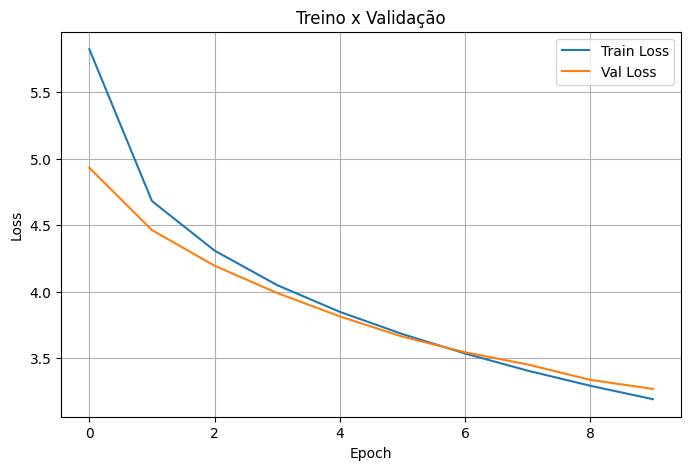

In [66]:
# Plota as curvas de perda do Treino e Validação

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
if not(TRAIN_ONLY):
    plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
if not(TRAIN_ONLY):
    plt.title('Treino x Validação')
else:
    plt.title('Treino')

plt.legend()
plt.grid(True)
plt.show()

### 21. Inferência

In [67]:
# Aplicação de tradução, após treinar o modelo

@torch.no_grad()
def translate(model, sentence, max_len=None):
    model.eval()

    src_ids = encoding(sentence)

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device
    )

    # inicia com BOS = [CLS]
    tgt = torch.tensor(
        [[BOS_ID]],
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():
        if max_len is None:
            max_len = min(len(src_ids) + 30, 128)

        for _ in range(max_len):

            output = model(src, tgt)

            next_token = output[:, -1, :].argmax(dim=-1)

            tgt = torch.cat(
                [tgt, next_token.unsqueeze(1)],
                dim=1
            )

            # para quando gerar EOS = [SEP]
            if next_token.item() == EOS_ID:
                break

    return decoding(tgt.squeeze(0))

In [69]:
# Teste prático do tradutor

one_batch_src, one_batch_tgt = next(iter(test_loader))

random.seed(None) # remove a semente aleatória

i = random.randint(0, BATCH_SIZE)

original = decoding(one_batch_src[i].tolist())
print("Teste EN:", original)
print(100*'-')
print("Ground True:", decoding(one_batch_tgt[i].tolist()))
print(100*'-')
print("Modelo:", translate(model, original))

Teste EN: Did you wait for us?
----------------------------------------------------------------------------------------------------
Ground True: Você esperou por nós?
----------------------------------------------------------------------------------------------------
Modelo: Você estava por nós?
